# 3D Print Failure Prediction — Neural Network
**Cornell Tech MakerLAB Project**

Implements a feedforward neural network from scratch (NumPy only) with weighted binary cross-entropy, validation tuning, threshold selection, and final test evaluation.

In [1]:
import sys
sys.path.append("..")

import json
import pickle
import numpy as np
import matplotlib.pyplot as plt
from src.neural_network import NeuralNetwork

DATA_DIR = "../data/raw/processed"
MODEL_OUT = "../models/nn_weights.pkl"

## 1. Load preprocessed data

In [2]:
train = np.load(f"{DATA_DIR}/train.npz")
val   = np.load(f"{DATA_DIR}/val.npz")
test  = np.load(f"{DATA_DIR}/test.npz")

X_train, y_train = train["X"], train["y"]
X_val,   y_val   = val["X"],   val["y"]
X_test,  y_test  = test["X"],  test["y"]

with open(f"{DATA_DIR}/feature_cols.json") as f:
    feature_cols = json.load(f)

print("Train:", X_train.shape, "| Val:", X_val.shape, "| Test:", X_test.shape)
print("Class dist (train) — 0:", (y_train == 0).sum(), "| 1:", (y_train == 1).sum())

Train: (700, 20) | Val: (150, 20) | Test: (150, 20)
Class dist (train) — 0: 253 | 1: 447


## 2. Hyperparameter tuning on validation set

Grid search over hidden layer width, learning rate, L2 strength, and number of iterations. We tune only on `val.npz` — `test.npz` is untouched until final evaluation.

In [3]:
def binary_metrics(y_true, y_pred):
    tp = ((y_pred == 1) & (y_true == 1)).sum()
    fp = ((y_pred == 1) & (y_true == 0)).sum()
    fn = ((y_pred == 0) & (y_true == 1)).sum()
    tn = ((y_pred == 0) & (y_true == 0)).sum()
    acc       = (y_pred == y_true).mean()
    precision = tp / (tp + fp + 1e-12)
    recall    = tp / (tp + fn + 1e-12)
    f1        = 2 * precision * recall / (precision + recall + 1e-12)
    return {"acc": acc, "precision": precision, "recall": recall, "f1": f1, "tp": tp, "fp": fp, "fn": fn, "tn": tn}

hidden_grid = [(16,), (32,), (32, 16)]
lr_grid     = [0.001, 0.005, 0.01]
l2_grid     = [0.0, 1e-4]
iter_grid   = [500, 1000]

best_f1, best_config = -np.inf, None
results = []

for hidden_layers in hidden_grid:
    for lr in lr_grid:
        for l2 in l2_grid:
            for n_iter in iter_grid:
                model = NeuralNetwork(
                    hidden_layers=hidden_layers,
                    lr=lr,
                    n_iter=n_iter,
                    batch_size=None,
                    l2=l2,
                    random_state=42,
                )
                model.fit(X_train, y_train, class_weight="balanced")
                y_pred_val = model.predict(X_val)
                metrics = binary_metrics(y_val, y_pred_val)
                row = {
                    "hidden_layers": hidden_layers,
                    "lr": lr,
                    "l2": l2,
                    "n_iter": n_iter,
                    "val_f1": metrics["f1"],
                    "val_acc": metrics["acc"],
                    "val_recall": metrics["recall"],
                }
                results.append(row)
                if metrics["f1"] > best_f1:
                    best_f1 = metrics["f1"]
                    best_config = row

print(f"Best val F1: {best_f1:.4f}")
print(best_config)

Best val F1: 0.8770
{'hidden_layers': (32, 16), 'lr': 0.005, 'l2': 0.0, 'n_iter': 1000, 'val_f1': np.float64(0.8770053475930738), 'val_acc': np.float64(0.8466666666666667), 'val_recall': np.float64(0.8541666666666579)}


## 3. Train final model with best hyperparameters

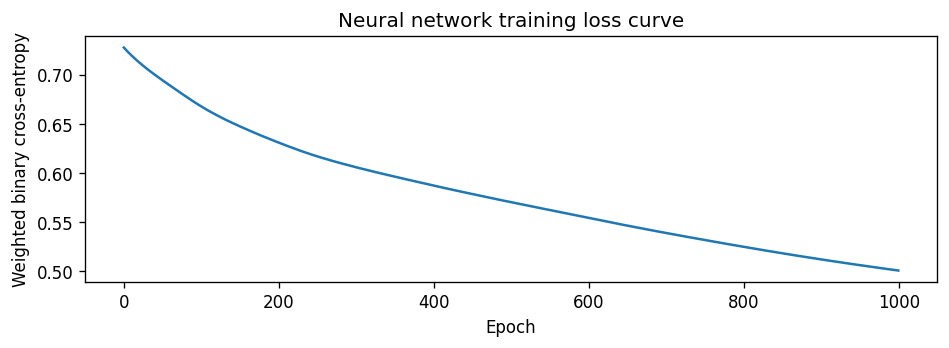

In [4]:
final_model = NeuralNetwork(
    hidden_layers=best_config["hidden_layers"],
    lr=best_config["lr"],
    n_iter=best_config["n_iter"],
    batch_size=None,
    l2=best_config["l2"],
    random_state=42,
)
final_model.fit(X_train, y_train, class_weight="balanced")

plt.figure(figsize=(8, 3))
plt.plot(final_model.loss_history)
plt.xlabel("Epoch")
plt.ylabel("Weighted binary cross-entropy")
plt.title("Neural network training loss curve")
plt.tight_layout()
plt.show()

## 4. Final evaluation on test set

In [5]:
def full_report(y_true, y_pred, split="Test"):
    metrics = binary_metrics(y_true, y_pred)
    print(f"--- {split} metrics ---")
    print(f"Accuracy:  {metrics['acc']:.4f}")
    print(f"Precision: {metrics['precision']:.4f}")
    print(f"Recall:    {metrics['recall']:.4f}")
    print(f"F1:        {metrics['f1']:.4f}")
    print(f"Confusion matrix:\n  TP={metrics['tp']} FP={metrics['fp']}\n  FN={metrics['fn']} TN={metrics['tn']}")

y_pred_test = final_model.predict(X_test)
full_report(y_test, y_pred_test, split="Test")

--- Test metrics ---
Accuracy:  0.8067
Precision: 0.8764
Recall:    0.8125
F1:        0.8432
Confusion matrix:
  TP=78 FP=11
  FN=18 TN=43


## 4b. Threshold tuning — optimize for recall

Default threshold is 0.5. For a failure-prediction safety tool, we want to minimize false negatives (missed failures). We sweep thresholds on the **val set** and pick the one that maximizes F1 while keeping recall high.

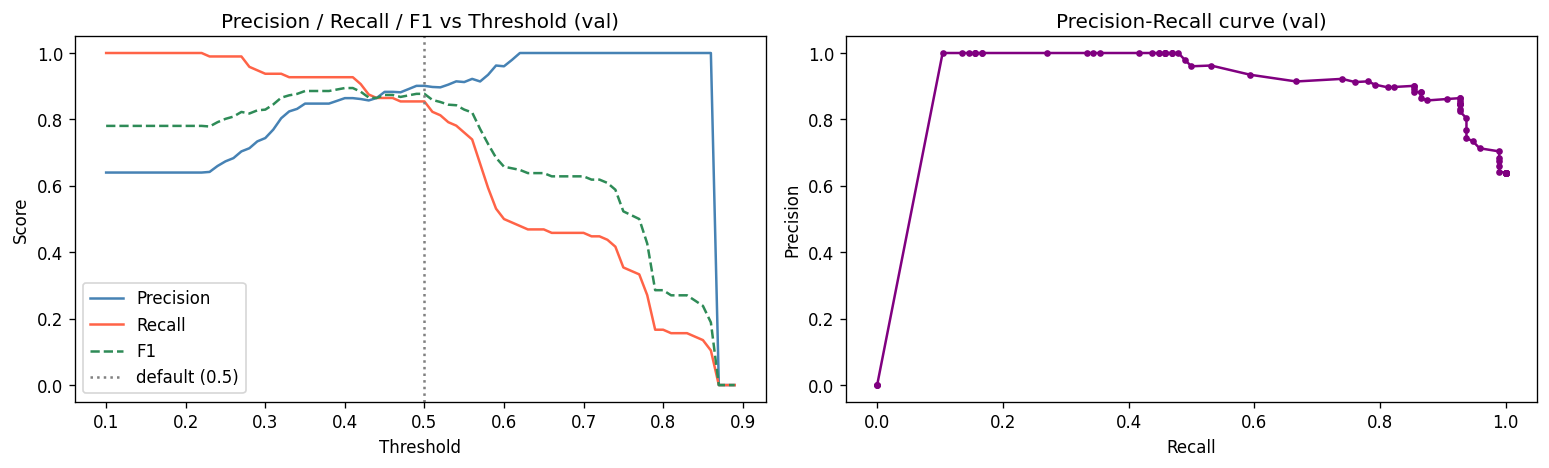

In [6]:
thresholds = np.arange(0.1, 0.9, 0.01)
val_proba = final_model.predict_proba(X_val)

precisions, recalls, f1s = [], [], []
for t in thresholds:
    y_pred = (val_proba >= t).astype(int)
    metrics = binary_metrics(y_val, y_pred)
    precisions.append(metrics["precision"])
    recalls.append(metrics["recall"])
    f1s.append(metrics["f1"])

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(thresholds, precisions, label="Precision", color="steelblue")
axes[0].plot(thresholds, recalls,    label="Recall",    color="tomato")
axes[0].plot(thresholds, f1s,        label="F1",        color="seagreen", linestyle="--")
axes[0].axvline(0.5, color="gray", linestyle=":", label="default (0.5)")
axes[0].set_xlabel("Threshold")
axes[0].set_ylabel("Score")
axes[0].set_title("Precision / Recall / F1 vs Threshold (val)")
axes[0].legend()

axes[1].plot(recalls, precisions, color="purple", marker=".")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall curve (val)")

plt.tight_layout()
plt.show()

In [7]:
target_recall = 0.90
candidates = [(t, f, p, r) for t, f, p, r in zip(thresholds, f1s, precisions, recalls) if r >= target_recall]

if candidates:
    best = max(candidates, key=lambda x: x[1])
    best_threshold, best_f1_t, best_prec_t, best_rec_t = best
    print(f"Best threshold for recall >= {target_recall}: {best_threshold:.2f}")
    print(f"  Val — Precision: {best_prec_t:.4f}  Recall: {best_rec_t:.4f}  F1: {best_f1_t:.4f}")
else:
    print(f"No threshold achieves recall >= {target_recall} on val set.")
    best_threshold = 0.5

final_model.threshold = best_threshold

Best threshold for recall >= 0.9: 0.40
  Val — Precision: 0.8641  Recall: 0.9271  F1: 0.8945


### Re-evaluate on test set with tuned threshold

In [8]:
test_proba = final_model.predict_proba(X_test)
y_pred_tuned = (test_proba >= best_threshold).astype(int)

print(f"Threshold: {best_threshold:.2f}  (default was 0.50)\n")
print("--- Default threshold (0.50) ---")
full_report(y_test, y_pred_test, split="Test")
print()
print(f"--- Tuned threshold ({best_threshold:.2f}) ---")
full_report(y_test, y_pred_tuned, split="Test")

Threshold: 0.40  (default was 0.50)

--- Default threshold (0.50) ---
--- Test metrics ---
Accuracy:  0.8067
Precision: 0.8764
Recall:    0.8125
F1:        0.8432
Confusion matrix:
  TP=78 FP=11
  FN=18 TN=43

--- Tuned threshold (0.40) ---
--- Test metrics ---
Accuracy:  0.8200
Precision: 0.8286
Recall:    0.9062
F1:        0.8657
Confusion matrix:
  TP=87 FP=18
  FN=9 TN=36


## 5. Feature importance (input sensitivity)

Neural network weights are less directly interpretable than logistic regression coefficients. As a lightweight model-explorer proxy, we rank features by average absolute connection strength from each input into the first hidden layer.

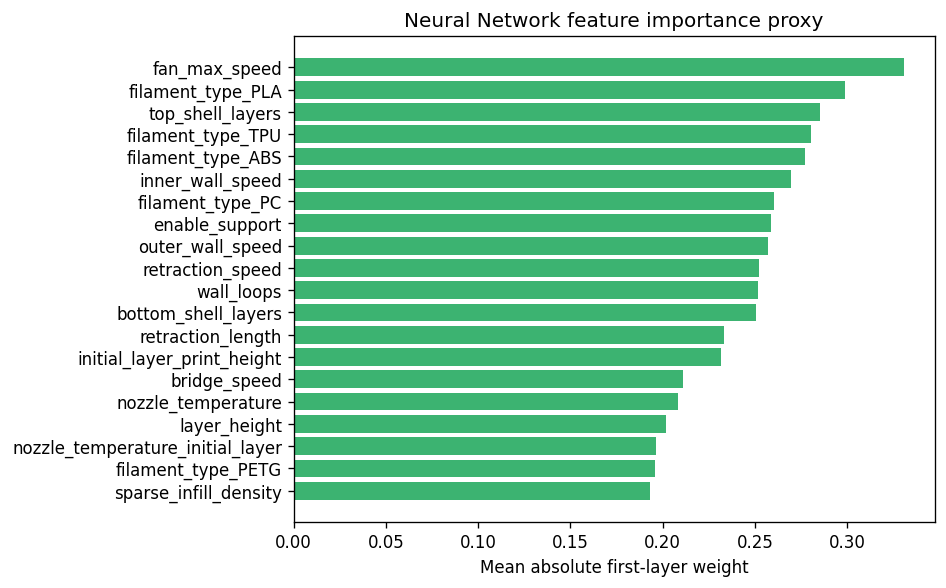

In [9]:
W1 = final_model.params["W1"]
importance = np.mean(np.abs(W1), axis=1)
sorted_idx = np.argsort(importance)[::-1]
sorted_importance = importance[sorted_idx]
sorted_features = [feature_cols[i] for i in sorted_idx]

plt.figure(figsize=(8, 5))
plt.barh(sorted_features[::-1], sorted_importance[::-1], color="mediumseagreen")
plt.xlabel("Mean absolute first-layer weight")
plt.title("Neural Network feature importance proxy")
plt.tight_layout()
plt.show()

## 6. Save model weights → `nn_weights.pkl`

In [10]:
with open(MODEL_OUT, "wb") as f:
    pickle.dump(final_model.params | {"threshold": best_threshold}, f)

print(f"Saved to {MODEL_OUT}")
print(f"hidden_layers: {best_config['hidden_layers']}, threshold: {best_threshold:.2f}")
print("Saved keys:", sorted(list(final_model.params.keys()) + ["threshold"]))

Saved to ../models/nn_weights.pkl
hidden_layers: (32, 16), threshold: 0.40
Saved keys: ['W1', 'W2', 'W_out', 'b1', 'b2', 'b_out', 'n_layers', 'threshold']
